In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from sklearn.pipeline import Pipeline

In [2]:
counts = pd.read_csv("TCGA_KIRC_counts.csv",index_col=0)
metadata = pd.read_csv("TCGA_KIRC_sample_metadata.csv")
genes = pd.read_csv("TCGA_KIRC_gene_annotation.csv")


In [3]:
print("Counts:")
print(counts.head())
print("\nMetadata:")
print(metadata.head())

Counts:
                    TCGA-B8-4146-01B-11R-1672-07  \
ENSG00000000003.15                          5898   
ENSG00000000005.6                             38   
ENSG00000000419.13                          3222   
ENSG00000000457.14                           910   
ENSG00000000460.17                           358   

                    TCGA-BP-4977-01A-01R-1334-07  \
ENSG00000000003.15                          5388   
ENSG00000000005.6                            312   
ENSG00000000419.13                          1465   
ENSG00000000457.14                          1102   
ENSG00000000460.17                           307   

                    TCGA-BP-4981-01A-01R-1334-07  \
ENSG00000000003.15                          1803   
ENSG00000000005.6                             17   
ENSG00000000419.13                          1035   
ENSG00000000457.14                           344   
ENSG00000000460.17                           111   

                    TCGA-CJ-5675-01A-11R-1541-07  \
E

In [4]:
print("Counts:")
print(counts.shape)
print(metadata.shape)

Counts:
(60660, 614)
(614, 71)


In [5]:
metadata= metadata[metadata["sample_type"] != "Additional - New Primary"]
metadata["sample_type"].value_counts()
counts = counts[metadata["barcode"]]

In [6]:
counts.columns[:5]

Index(['TCGA-B8-4146-01B-11R-1672-07', 'TCGA-BP-4977-01A-01R-1334-07',
       'TCGA-BP-4981-01A-01R-1334-07', 'TCGA-CJ-5675-01A-11R-1541-07',
       'TCGA-B0-4845-01A-01R-1277-07'],
      dtype='str')

In [7]:
metadata["barcode"].head(10)

0    TCGA-B8-4146-01B-11R-1672-07
1    TCGA-BP-4977-01A-01R-1334-07
2    TCGA-BP-4981-01A-01R-1334-07
3    TCGA-CJ-5675-01A-11R-1541-07
4    TCGA-B0-4845-01A-01R-1277-07
5    TCGA-B4-5377-01A-01R-1503-07
6    TCGA-B8-5163-01A-01R-1420-07
7    TCGA-B0-5092-01A-01R-1420-07
8    TCGA-AK-3458-01A-01R-1503-07
9    TCGA-BP-4161-01A-02R-1325-07
Name: barcode, dtype: str

In [8]:
all(counts.columns == metadata["barcode"])

True

In [9]:
X = counts.T
y = metadata["sample_type"]

print(X.shape)
print(y.shape)

(613, 60660)
(613,)


In [10]:
mask = (counts >=10).sum(axis=1) >=20
counts_filtered = counts.loc[mask]

print(f"Genes originales {counts.shape[0]}")
print(f"Genes filtrados {counts_filtered.shape[0]}")

Genes originales 60660
Genes filtrados 30260


In [11]:
X = counts_filtered.T
print(X.shape)

(613, 30260)


In [12]:
X_log = np.log2(X + 1)

In [13]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print(encoder.classes_)

['Primary Tumor' 'Solid Tissue Normal']


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PC1:",round(pca.explained_variance_ratio_[0]*100,2), "%")
print("PC2:",round(pca.explained_variance_ratio_[1]*100,2), "%")

PC1: 20.31 %
PC2: 11.7 %


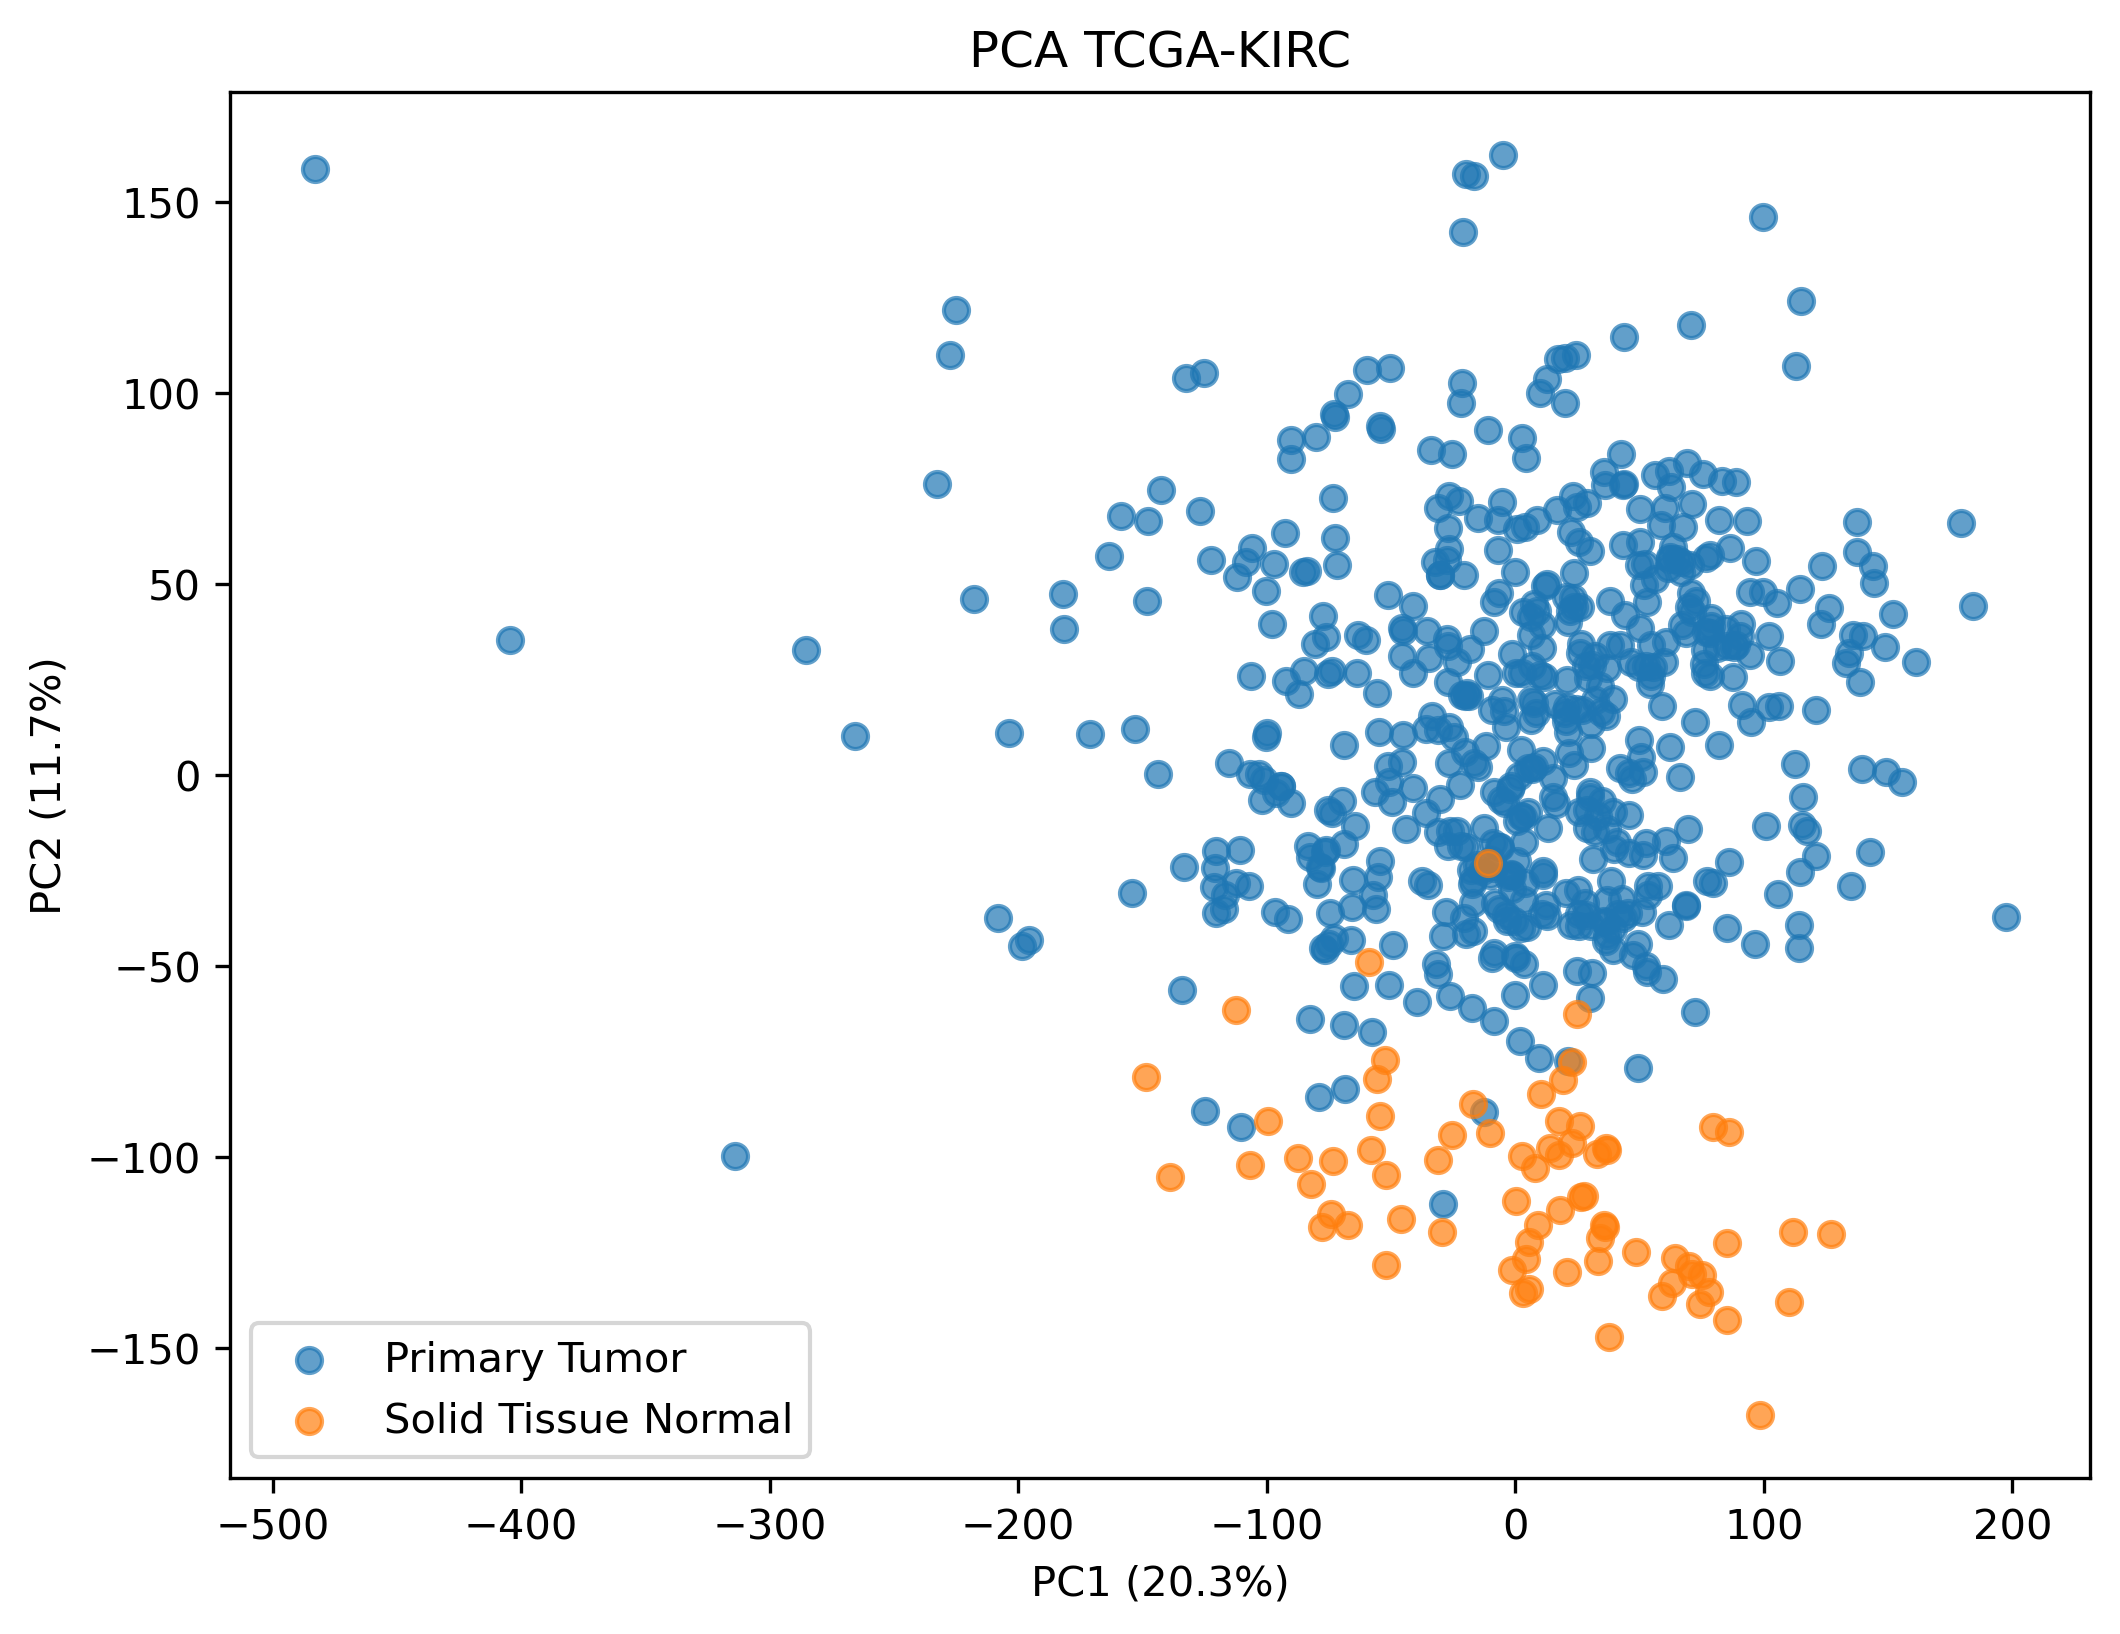

In [16]:
pca_df = pd.DataFrame({"PC1": X_pca[:,0],"PC2": X_pca[:,1],"Group": y})

plt.figure(figsize=(8,6), dpi=300)

for grupo in pca_df["Group"].unique():
    subset = pca_df[pca_df["Group"] == grupo]
    plt.scatter(subset["PC1"],subset["PC2"],label=grupo,alpha=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA TCGA-KIRC")
plt.legend()

plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)
print(X_train.shape)
print(X_test.shape)
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

(429, 30260)
(184, 30260)
0    379
1     50
Name: count, dtype: int64
0    162
1     22
Name: count, dtype: int64


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)
y_pred = modelo.predict(X_test_scaled)

In [20]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.9945652173913043
Precision: 1.0
Recall   : 0.9545454545454546
F1-score : 0.9767441860465116


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[162   0]
 [  1  21]]


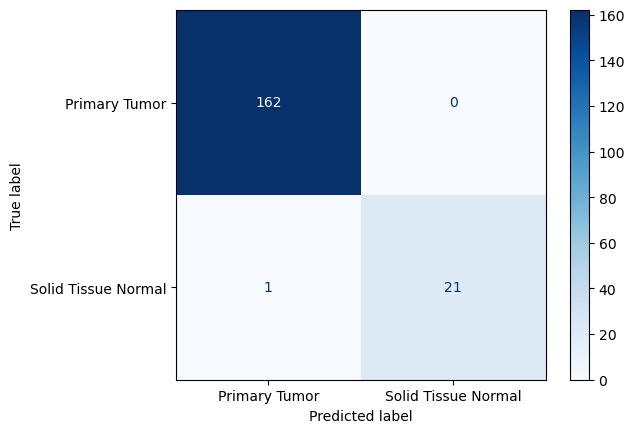

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(cm,display_labels=encoder.classes_)
disp.plot(cmap="Blues")
plt.show()

In [23]:
print(classification_report(y_test,y_pred,target_names=encoder.classes_))

                     precision    recall  f1-score   support

      Primary Tumor       0.99      1.00      1.00       162
Solid Tissue Normal       1.00      0.95      0.98        22

           accuracy                           0.99       184
          macro avg       1.00      0.98      0.99       184
       weighted avg       0.99      0.99      0.99       184



In [30]:
coef = modelo.coef_[0]

coef_df = pd.DataFrame({
    "Gene": X.columns,
    "Coefficient": coef
})

coef_df.head()

,Gene,Coefficient
0,ENSG00000000003.15,0.000191
1,ENSG00000000005.6,-0.000840
2,ENSG00000000419.13,-0.000466
3,ENSG00000000457.14,-0.000794
4,ENSG00000000460.17,-0.003812


In [31]:
coef_df["abs_coef"] = np.abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by = "abs_coef",
    ascending= False
)

coef_df.head(20)

,Gene,Coefficient,abs_coef
25536,ENSG00000263429.3,0.019472,0.019472
8464,ENSG00000146250.7,0.017196,0.017196
24203,ENSG00000257746.2,0.017121,0.017121
29421,ENSG00000286176.2,0.017121,0.017121
29222,ENSG00000285640.1,0.016900,0.016900
18850,ENSG00000226886.1,0.016883,0.016883
4348,ENSG00000115705.22,-0.016799,0.016799
2910,ENSG00000104879.5,0.016702,0.016702
9453,ENSG00000155622.7,0.016117,0.016117
11042,ENSG00000165272.16,0.016014,0.016014


In [35]:
print("Genes asociados a tejido normal")
display(
    coef_df.sort_values("Coefficient", ascending=False).head(20)
)

print("\nGenes asociados a tumor")
display(
    coef_df.sort_values("Coefficient", ascending=True).head(20))

Genes asociados a tejido normal


,Gene,Coefficient,abs_coef
25536,ENSG00000263429.3,0.019472,0.019472
8464,ENSG00000146250.7,0.017196,0.017196
24203,ENSG00000257746.2,0.017121,0.017121
29421,ENSG00000286176.2,0.017121,0.017121
29222,ENSG00000285640.1,0.016900,0.016900
18850,ENSG00000226886.1,0.016883,0.016883
2910,ENSG00000104879.5,0.016702,0.016702
9453,ENSG00000155622.7,0.016117,0.016117
11042,ENSG00000165272.16,0.016014,0.016014
24188,ENSG00000257634.1,0.015744,0.015744



Genes asociados a tumor


,Gene,Coefficient,abs_coef
4348,ENSG00000115705.22,-0.016799,0.016799
26895,ENSG00000272046.1,-0.015078,0.015078
29998,ENSG00000287609.1,-0.015011,0.015011
22720,ENSG00000249481.7,-0.014796,0.014796
21994,ENSG00000242970.2,-0.013753,0.013753
30188,ENSG00000288056.1,-0.013570,0.013570
3881,ENSG00000112077.17,-0.013462,0.013462
18759,ENSG00000226478.3,-0.013027,0.013027
8031,ENSG00000143355.16,-0.012795,0.012795
4045,ENSG00000113303.12,-0.012583,0.012583


In [48]:
tumor_mask = (y == "Primary Tumor").to_numpy()
normal_mask = (y == "Solid Tissue Normal").to_numpy()

X_tumor = X_log.iloc[tumor_mask]
X_normal = X_log.iloc[normal_mask]

print(X_tumor.shape)
print(X_normal.shape)

(541, 30260)
(72, 30260)


In [53]:
mean_tumor = X_tumor.mean(axis=0)
mean_normal = X_normal.mean(axis=0)

log2FC = mean_tumor- mean_normal

In [64]:
t_stat, p_values = ttest_ind(
    X_tumor,
    X_normal,
    axis= 0,
    equal_var=False
)

results = pd.DataFrame({
    "Gene": X_log.columns,
    "log2FC": log2FC.values,
    "p_values": p_values})

results.head(10)

,Gene,log2FC,p_values
0,ENSG00000000003.15,-1.473416,2.896265e-29
1,ENSG00000000005.6,-2.345382,1.557286e-19
2,ENSG00000000419.13,-0.248056,4.829074e-05
3,ENSG00000000457.14,-0.545071,1.047290e-13
4,ENSG00000000460.17,0.408232,5.443330e-07
5,ENSG00000000938.13,1.272312,4.898223e-23
6,ENSG00000000971.16,0.120042,3.672074e-01
7,ENSG00000001036.14,-0.065769,2.503111e-01
8,ENSG00000001084.13,-0.051738,4.737831e-01
9,ENSG00000001167.14,-0.215626,4.212653e-03


In [79]:
_, fdr, _, _= multipletests(
    p_values,
    alpha=0.05,
    method="fdr_bh"
)
results["FDR"] = fdr
results = results.sort_values("FDR")

results.head(20)

,Gene,log2FC,p_values,FDR
10018,ENSG00000160323.19,-0.388390,2.050322e-05,5.182160e-125
17029,ENSG00000211649.3,1.531494,1.095125e-06,3.233691e-123
12564,ENSG00000172361.6,-0.717271,8.856706e-20,1.210458e-121
22775,ENSG00000249767.1,0.336983,3.072844e-03,8.406003e-121
5016,ENSG00000121542.12,0.031605,6.206379e-01,1.432903e-120
7847,ENSG00000141744.4,-3.333124,3.781207e-31,1.542481e-116
12913,ENSG00000174437.17,-0.057401,3.900212e-01,6.448703e-115
5729,ENSG00000127603.30,-0.683583,1.062563e-13,4.183638e-114
23108,ENSG00000251350.2,0.280653,1.047258e-01,3.456987e-113
9655,ENSG00000157445.15,-2.401578,1.222721e-41,8.042173e-112


In [82]:
deg = results[
    (results["FDR"] < 0.05) &
    (np.abs(results["log2FC"] > 1))]

print(f" Genes diferencialmente expresados: {deg}")

 Genes diferencialmente expresados:                      Gene    log2FC      p_values            FDR
17029   ENSG00000211649.3  1.531494  1.095125e-06  3.233691e-123
4389   ENSG00000116014.10  5.842582  5.144224e-60   8.643044e-96
21605   ENSG00000240038.6  1.145572  5.008831e-19   1.239659e-95
26768   ENSG00000271553.1  1.027748  8.653267e-14   6.668068e-93
19460   ENSG00000229487.1  1.463037  5.743895e-21   4.043979e-92
...                   ...       ...           ...            ...
3238   ENSG00000106560.11  1.065559  1.027329e-21   4.659640e-02
25469   ENSG00000262873.2  1.011994  3.432882e-18   4.813756e-02
21054   ENSG00000236453.5  1.567101  1.241662e-09   4.941594e-02
9061   ENSG00000151882.11  1.089592  8.878831e-10   4.945445e-02
6675   ENSG00000134690.11  1.253985  5.089073e-19   4.983399e-02

[4000 rows x 4 columns]


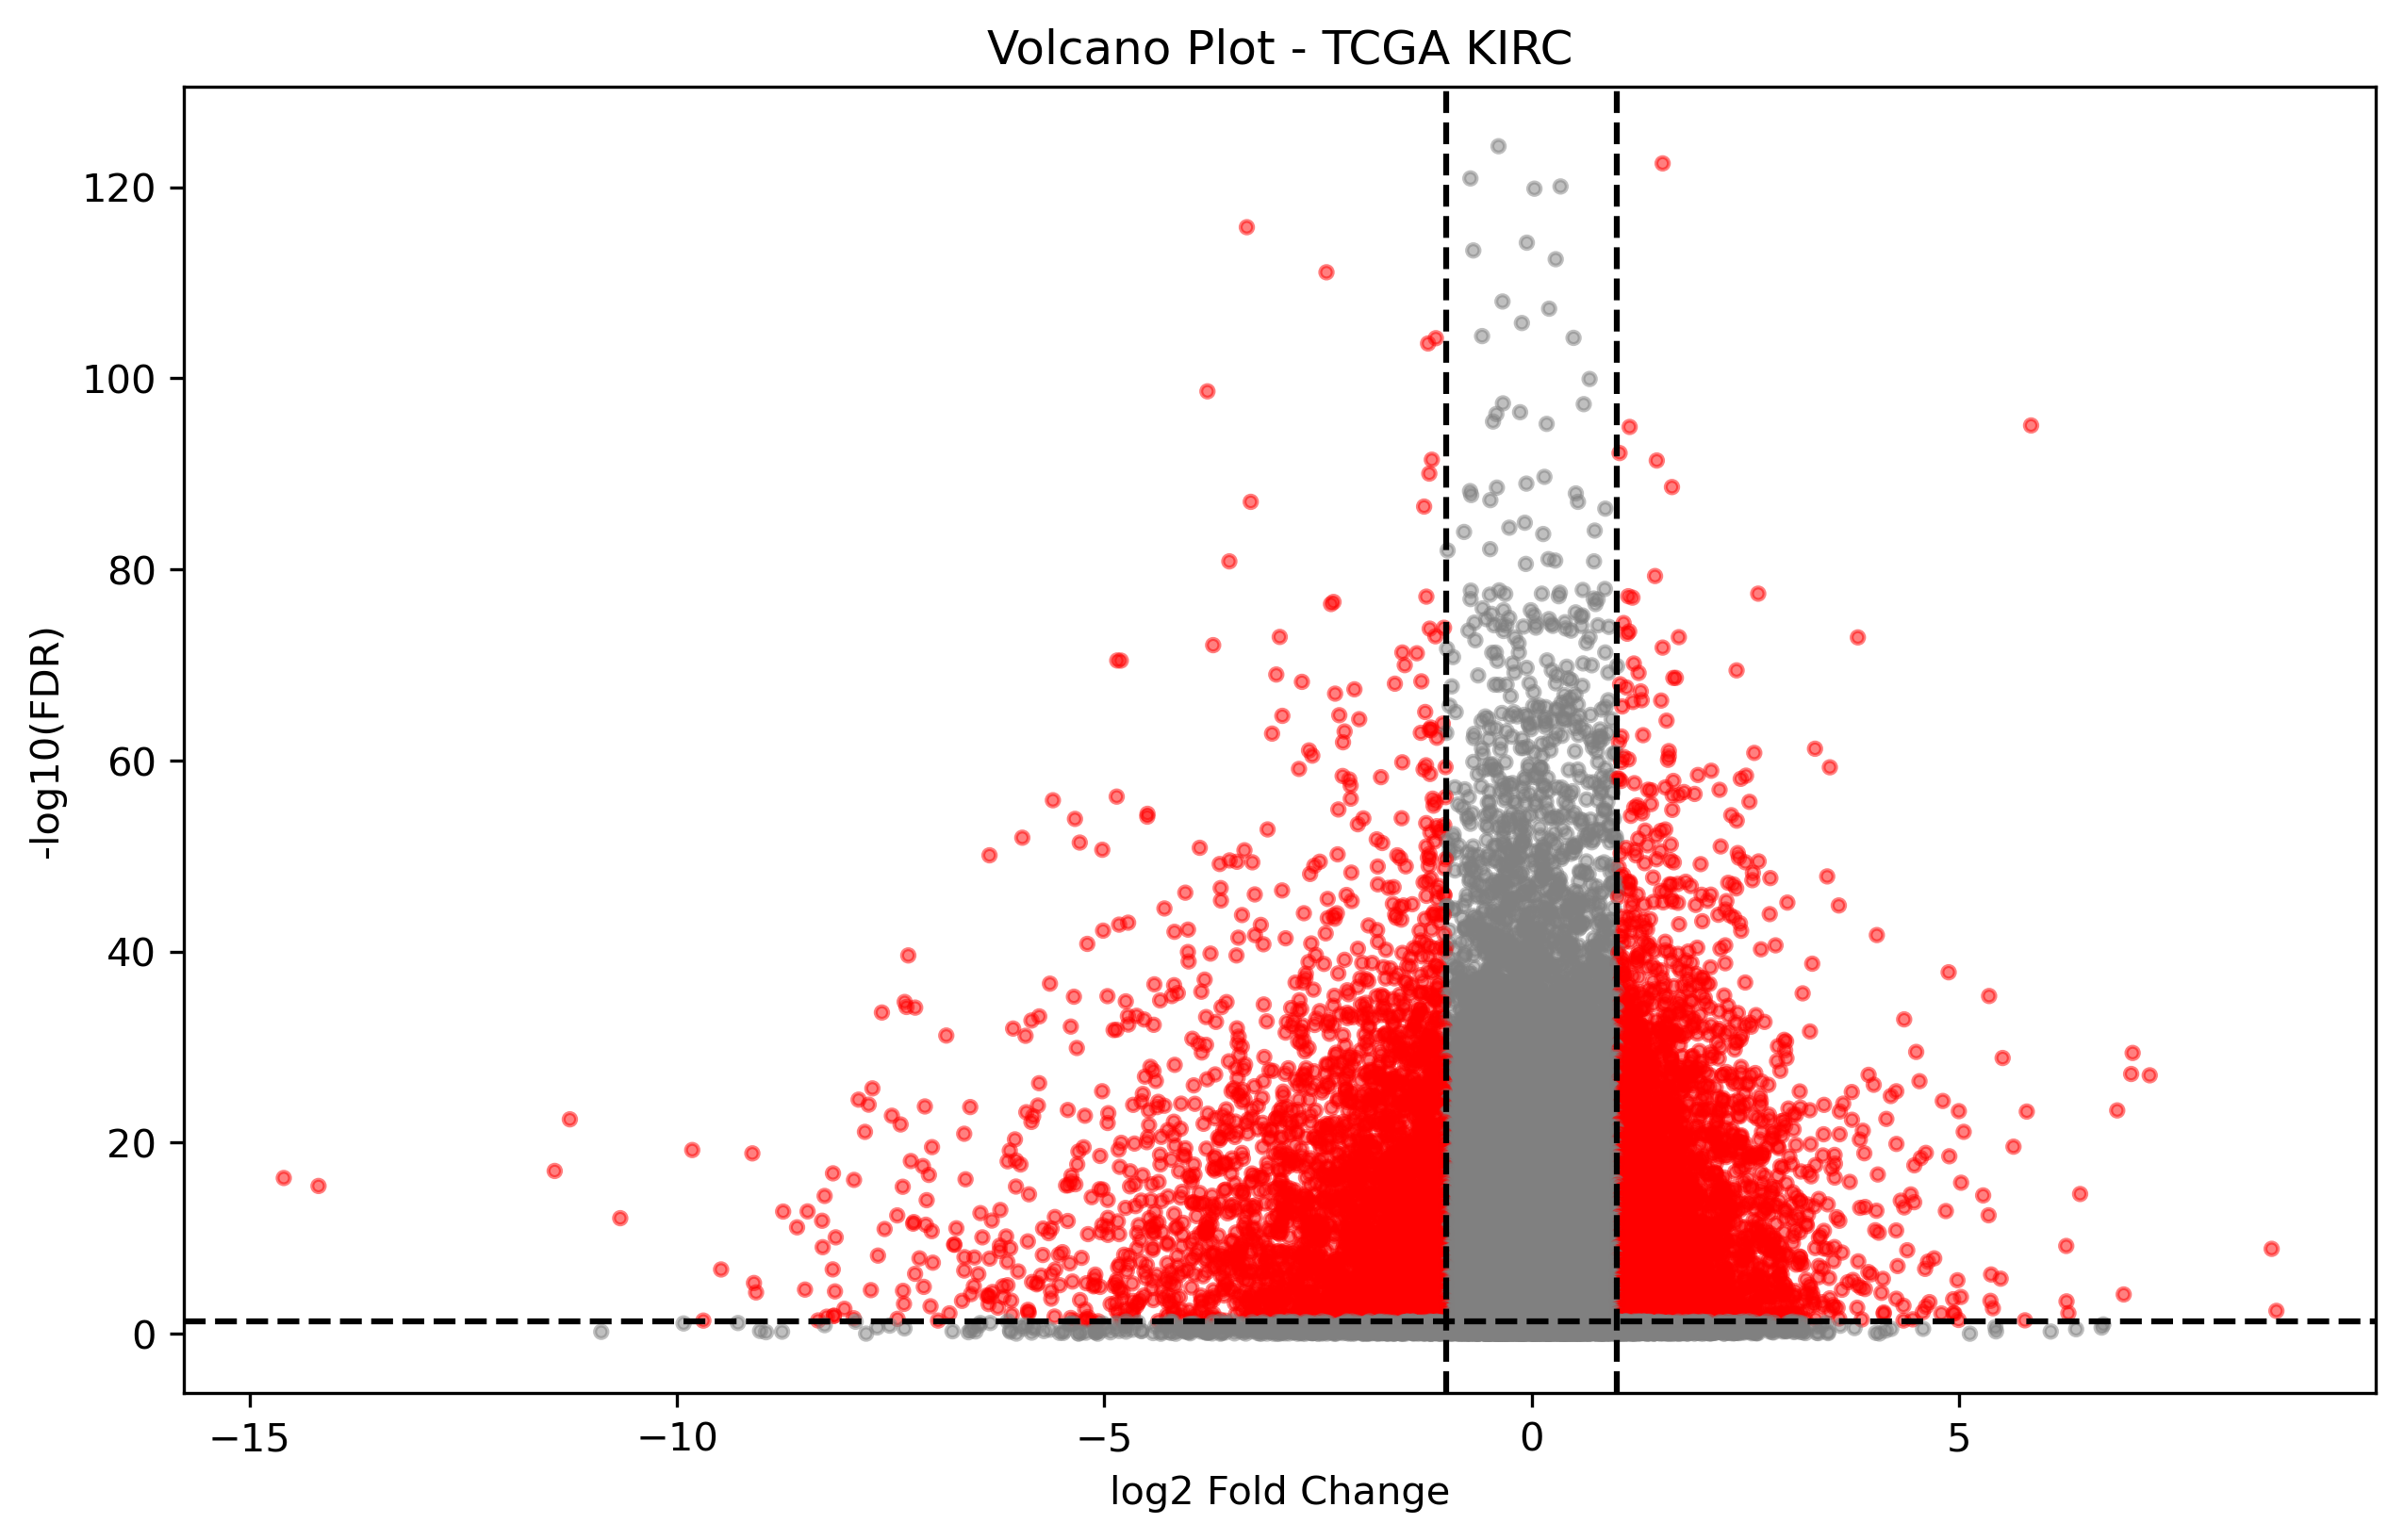

In [86]:
results["minus_log10_FDR"] = -np.log10(results["FDR"])

results["Significant"] = (
    (results["FDR"] < 0.05) &
    (np.abs(results["log2FC"]) > 1)
)

plt.figure(figsize=(10,6), dpi=300)

plt.scatter(
    results["log2FC"],
    results["minus_log10_FDR"],
    c=results["Significant"].map({True:"red",False:"gray"}),
    alpha=0.5,
    s=10
)

plt.axvline(1,color="black",linestyle="--")
plt.axvline(-1,color="black",linestyle="--")
plt.axhline(-np.log10(0.05),color="black",linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot - TCGA KIRC")

plt.show()